# Reto 1 · Resultados que permiten comparar

Este punto de entrada evita la métrica saturada de «mejor solución observada». Regenera seis figuras y cuatro tablas para responder: calidad típica, probabilidad por tiro, costo del circuito, sensibilidad del optimizador y efecto observado en SelenePlus.

In [1]:
from pathlib import Path
import runpy
import pandas as pd
from IPython.display import Image, display

ROOT = next(
    ruta for ruta in [Path.cwd(), Path.cwd().parent]
    if (ruta / "config.yaml").exists()
)
FIGURAS = ROOT / "figuras"
TABLAS = ROOT / "resultados" / "tablas_finales"
runpy.run_path(str(ROOT / "scripts" / "generar_figuras.py"))

Seis figuras y cuatro tablas finales regeneradas correctamente.


{'__name__': '<run_path>',
 '__doc__': None,
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': '/home/jovyan/reto1_qaoa_noir/scripts/generar_figuras.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjects with the same name as a built-in value, but in\nwhich the built-in of that name is also needed.",
  '__package__': '',
  '__loader__': _frozen_importlib.BuiltinImporter,
  '__spec__': ModuleSpec(name='builtins', loader=<class '_frozen_importlib.BuiltinImporter'>, origin='built-in'),
  '__build_class__': <function __build_class__>,
  '__import__': <function __import__(name, globals=None, locals=None, fro

## 1. Calidad esperada y probabilidad por tiro

La razón media describe la calidad de una muestra típica. La probabilidad de óptimo se reporta **por tiro**: usar «al menos un óptimo en 512 tiros» oculta las diferencias porque esa probabilidad se aproxima a 1 incluso cuando el estado asigna poca masa al óptimo.

,n,p,razon_ideal,razon_muestral_media,razon_muestral_std,probabilidad_optimo_ideal,optimos_esperados_en_512
0,6,1,0.838432,0.839777,0.004985,0.157418,80.597763
1,6,2,0.878059,0.878151,0.004335,0.218421,111.831801
2,6,3,0.917346,0.918513,0.004864,0.379235,194.168202
3,8,1,0.811577,0.811391,0.006941,0.046878,24.001671
4,8,2,0.854904,0.854542,0.003368,0.076807,39.325174
5,8,3,0.894451,0.895175,0.004278,0.153491,78.587325
6,10,1,0.793778,0.792310,0.005303,0.016451,8.423056
7,10,2,0.843226,0.841456,0.004996,0.027111,13.881024
8,10,3,0.871222,0.872790,0.004041,0.042464,21.741362
9,12,1,0.780929,0.780782,0.008032,0.005385,2.756959


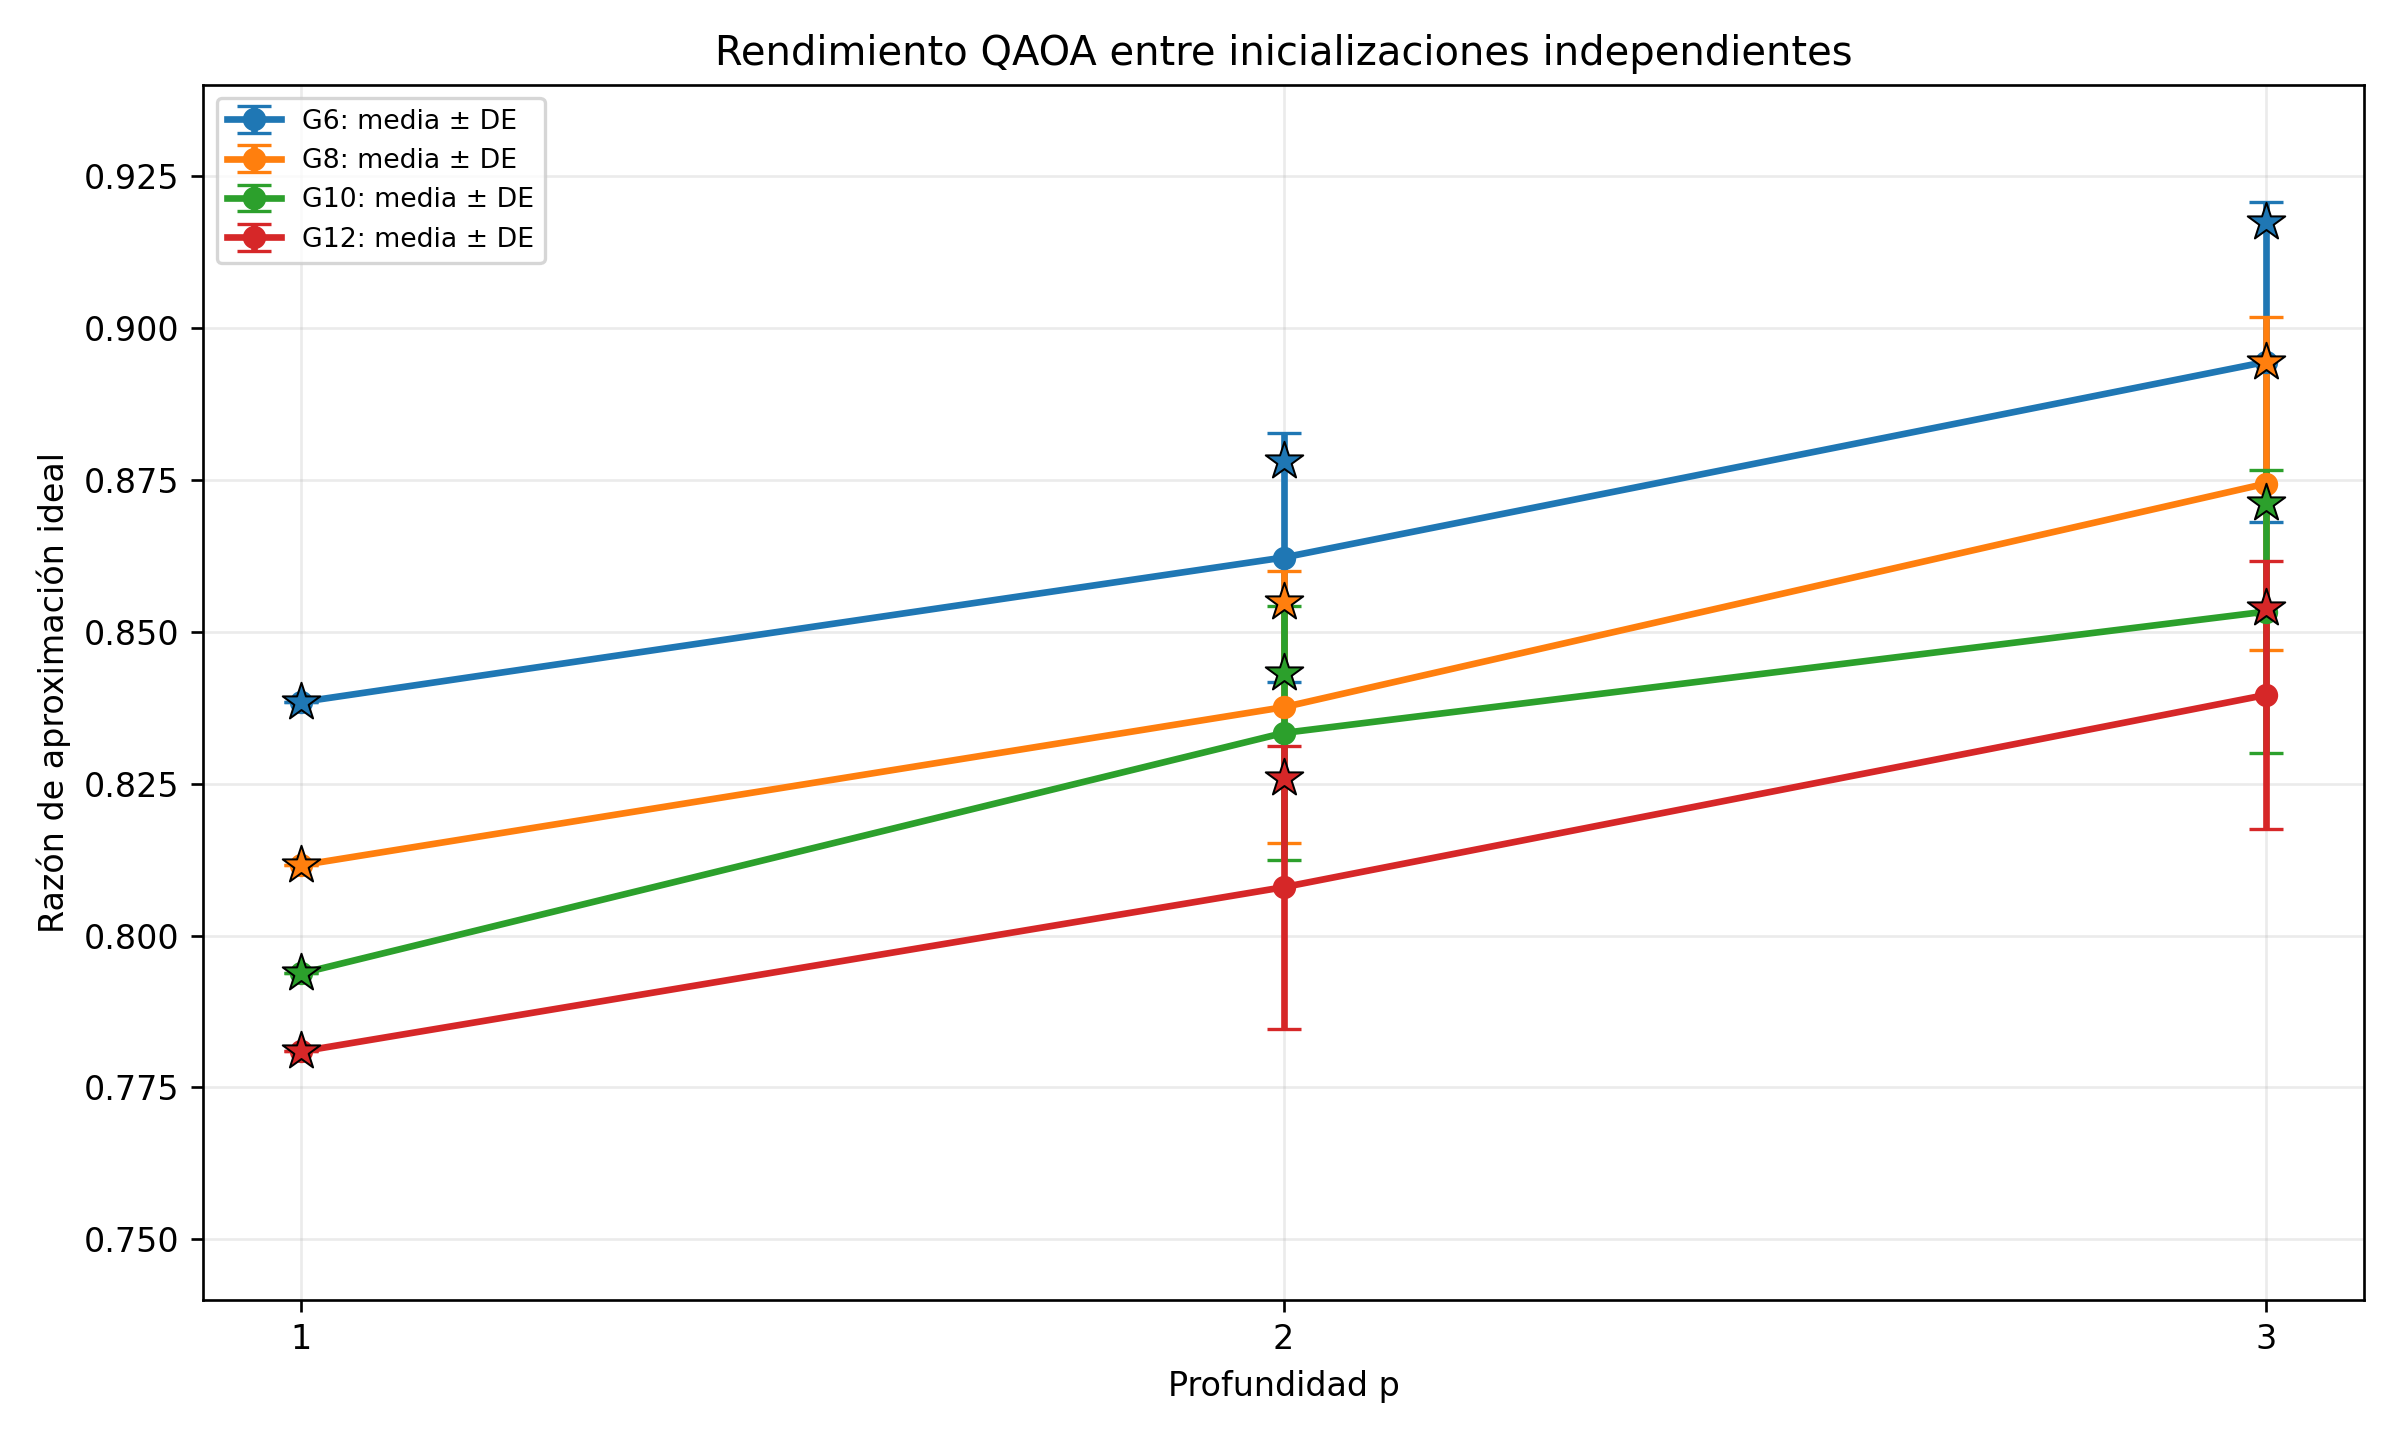

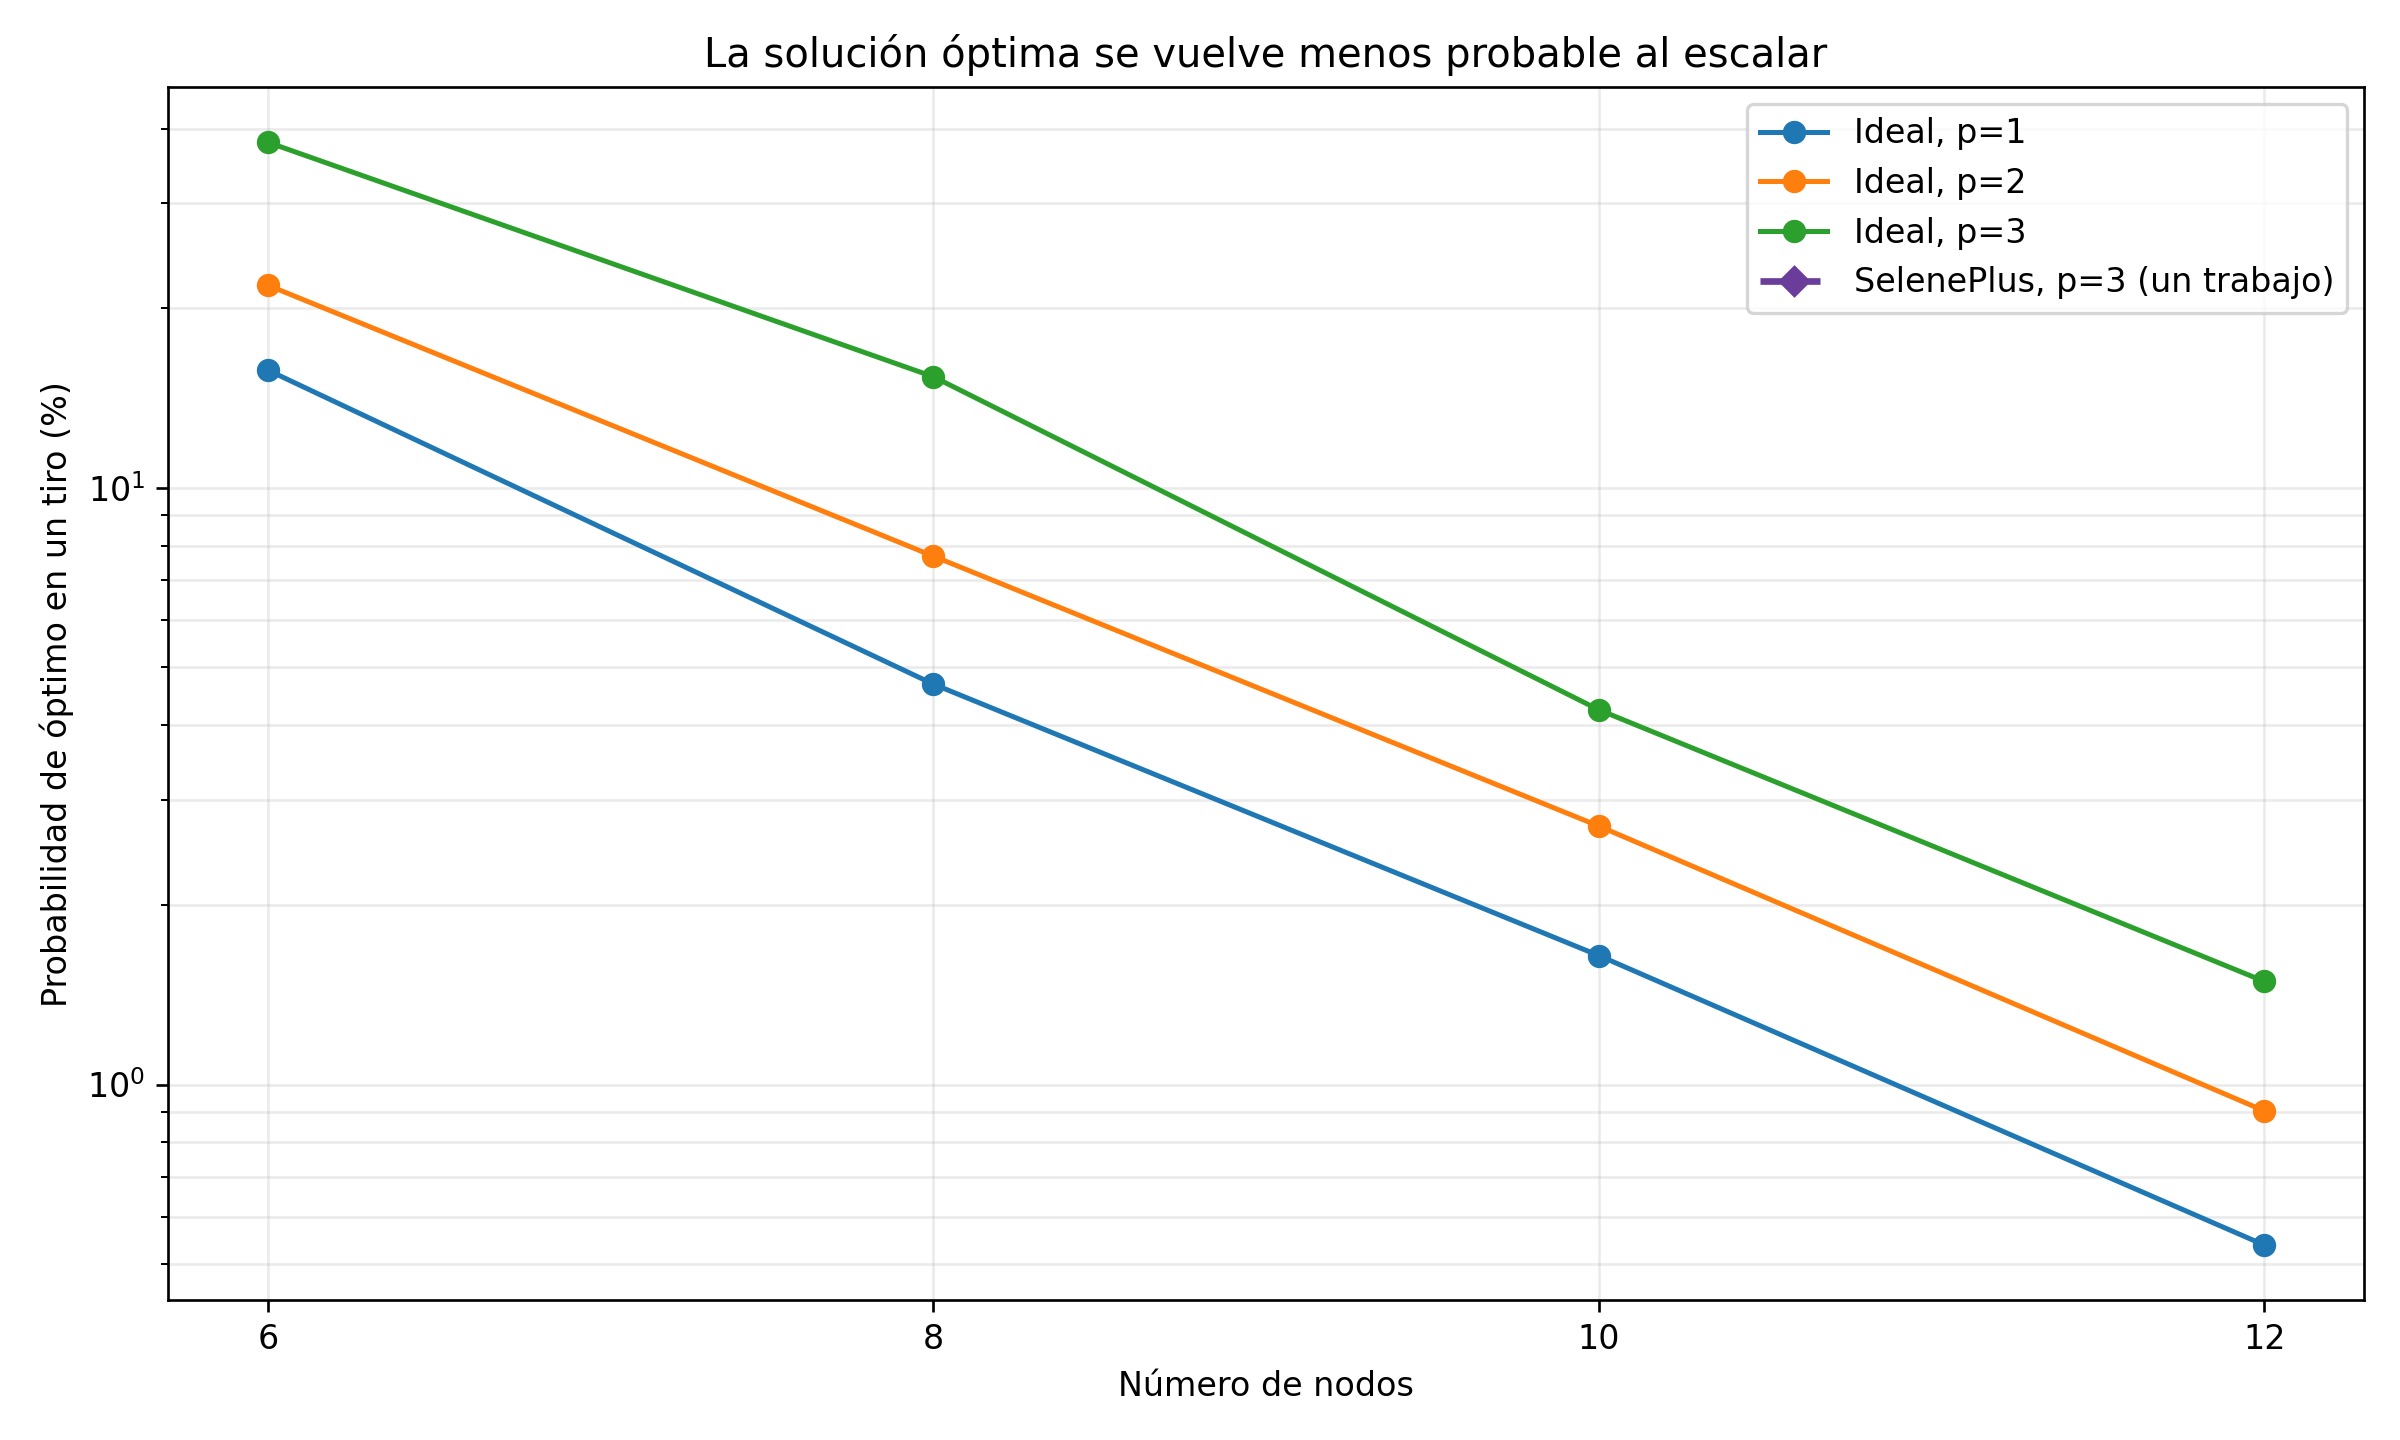

In [2]:
tradeoff = pd.read_csv(TABLAS / "01_tradeoff_profundidad.csv")
display(tradeoff[[
    "n", "p", "razon_ideal", "razon_muestral_media",
    "razon_muestral_std", "probabilidad_optimo_ideal",
    "optimos_esperados_en_512"
]].round(6))
display(Image(filename=str(FIGURAS / "01_razon_vs_p_inicializaciones.png")))
display(Image(filename=str(FIGURAS / "02_probabilidad_optimo_por_tiro.png")))

## 2. Comparación justa con métodos clásicos

Se compara rendimiento medio. Los métodos no tuvieron el mismo presupuesto de evaluaciones, por lo que la tabla conserva ese dato. El control aleatorio de 0.5 permanece en la tabla, pero se excluye de la figura para no comprimir artificialmente las diferencias entre los demás métodos.

metodo,Aleatorio teórico,Exacto,Goemans-Williamson,Greedy,"QAOA ideal p=3, 512 tiros",Recocido simulado,"SelenePlus p=3, 512 tiros"
n,,,,,,,
6,0.5,1.0,1.0,0.989440,0.918513,1.000000,0.672668
8,0.5,1.0,1.0,0.973997,0.895175,1.000000,0.518092
10,0.5,1.0,1.0,0.959880,0.872790,1.000000,0.514636
12,0.5,1.0,1.0,0.963989,0.853617,0.999005,0.500611


,n,metodo,razon_media,desviacion_razon,repeticiones_o_evaluaciones,origen
0,6,Aleatorio teórico,0.500000,NaN,0,clásico
1,6,Exacto,1.000000,0.000000,32,clásico
2,6,Goemans-Williamson,1.000000,0.000000,1000,clásico
3,6,Greedy,0.989440,0.038683,100,clásico
4,6,"QAOA ideal p=3, 512 tiros",0.918513,0.004864,30,30 lotes del mismo estado ideal optimizado
5,6,Recocido simulado,1.000000,0.000000,100,clásico
6,6,"SelenePlus p=3, 512 tiros",0.672668,NaN,1,un trabajo remoto con ruido
7,8,Aleatorio teórico,0.500000,NaN,0,clásico
8,8,Exacto,1.000000,0.000000,128,clásico
9,8,Goemans-Williamson,1.000000,0.000000,1000,clásico


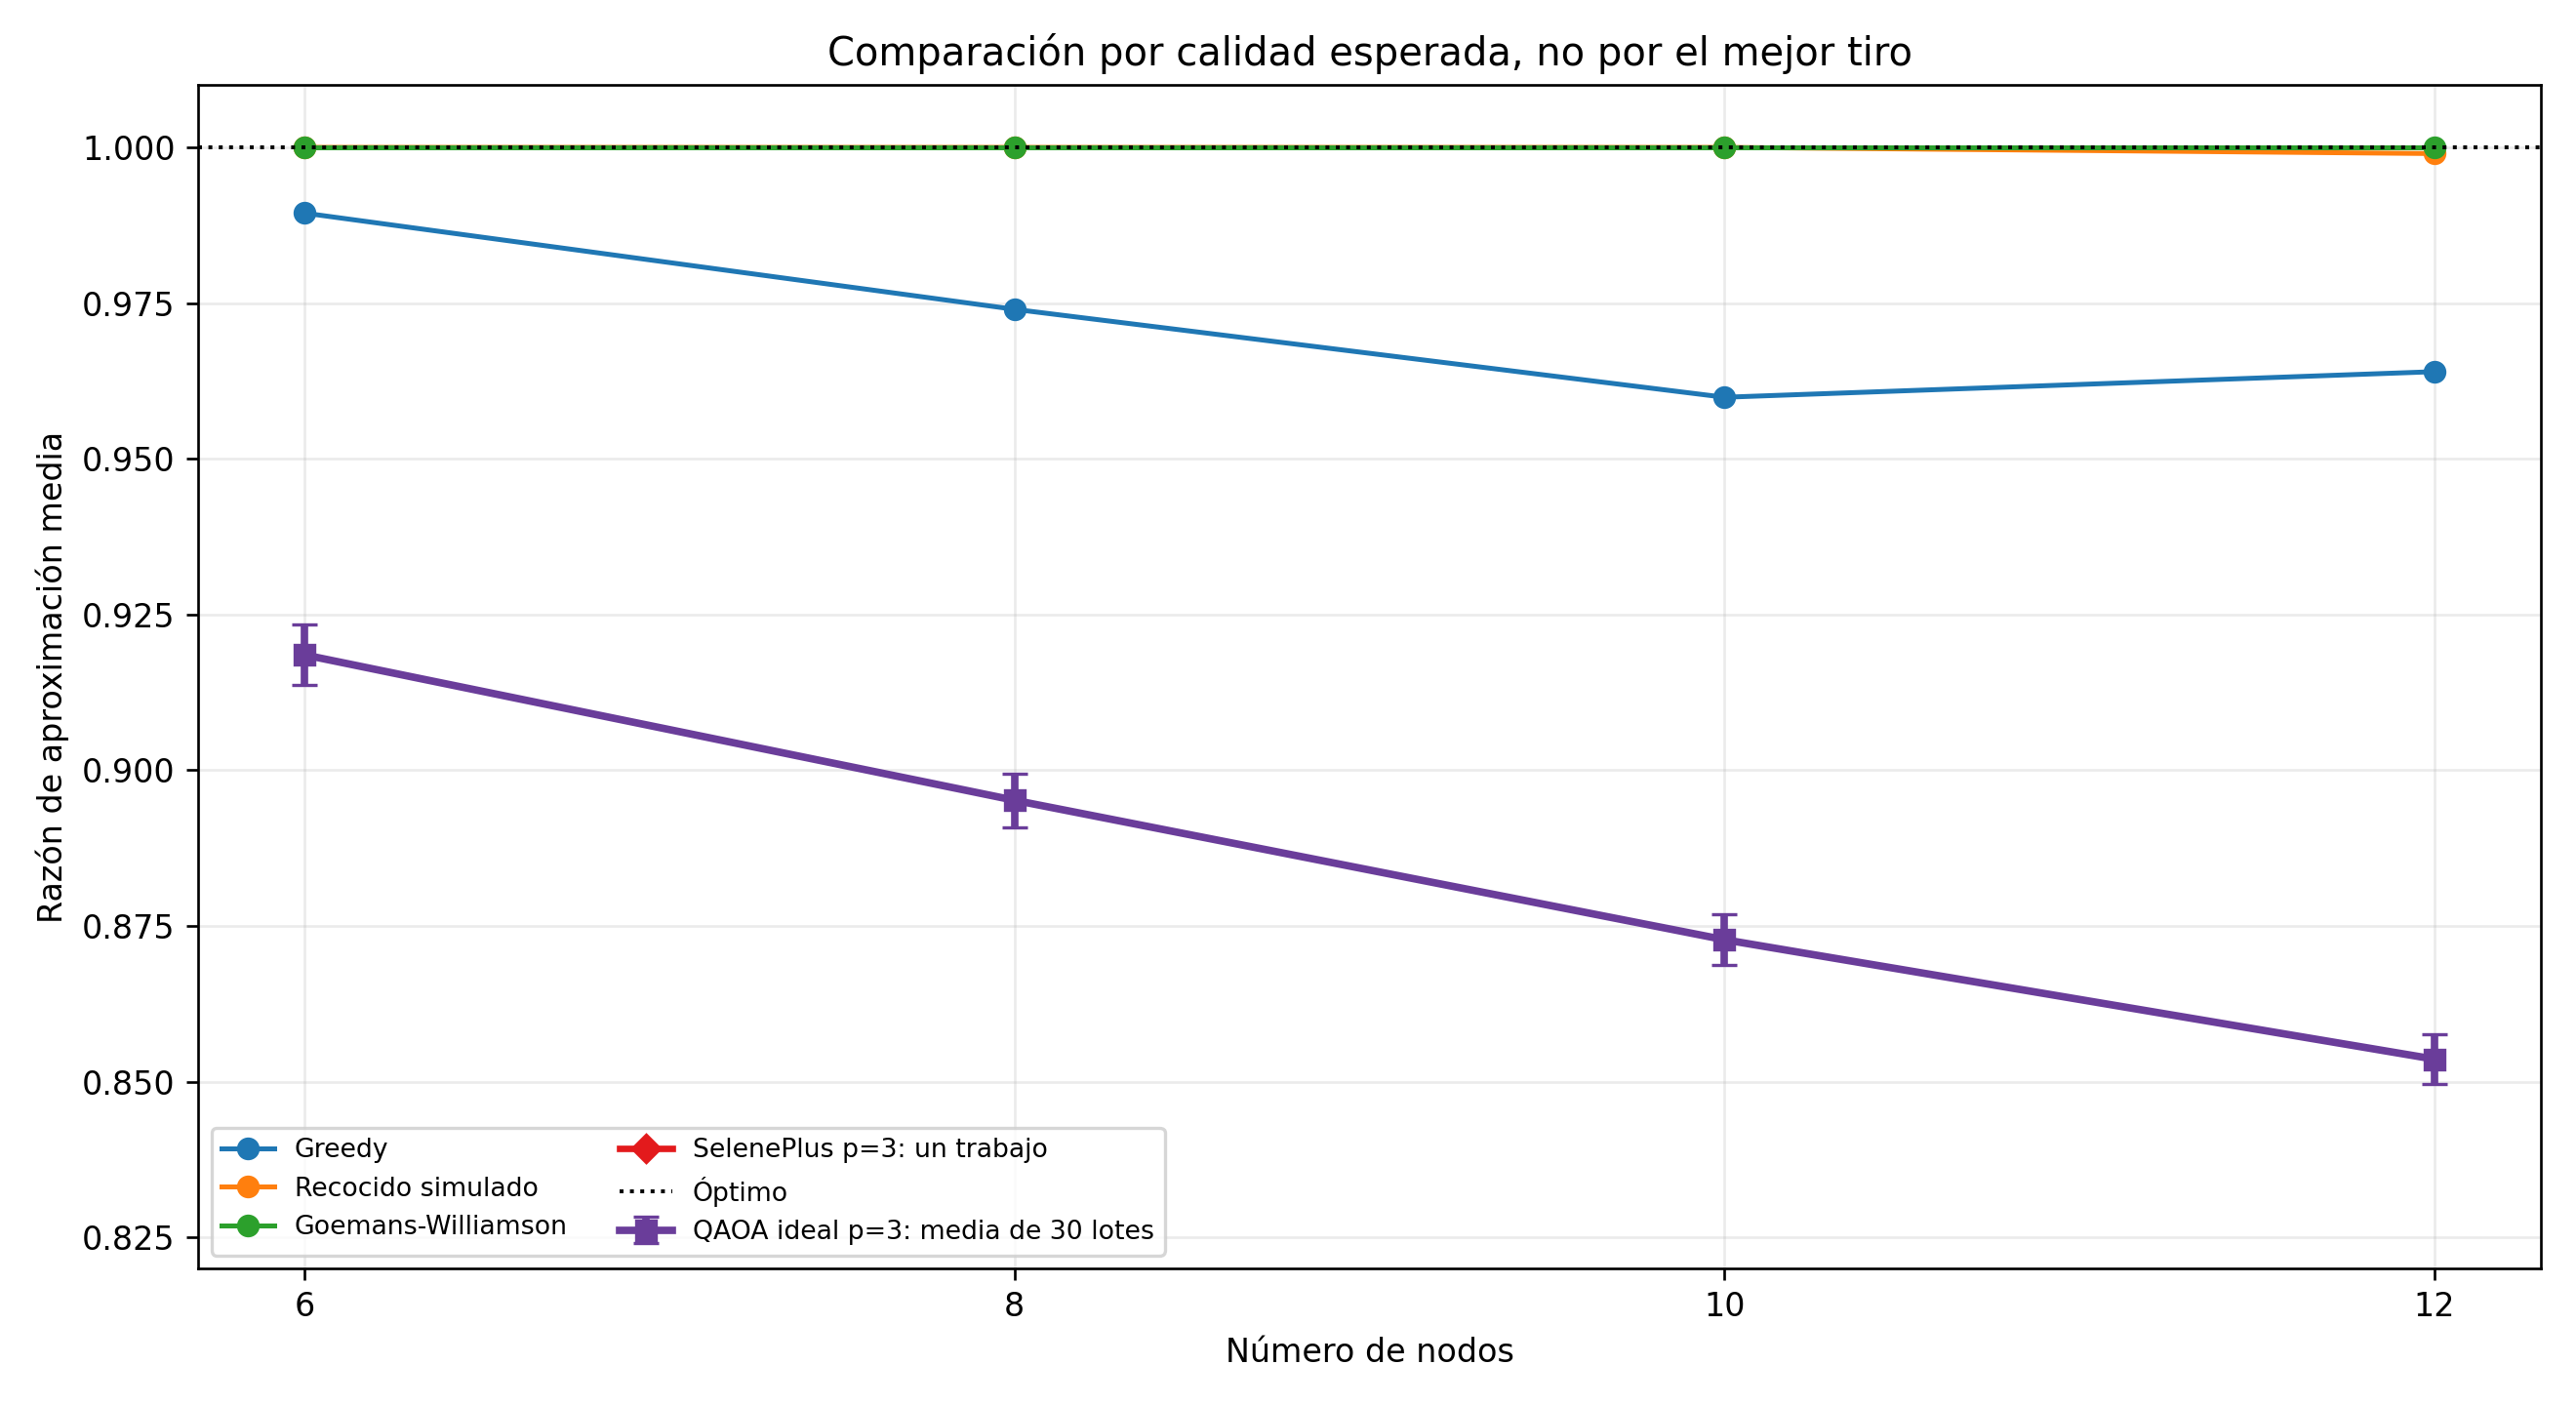

In [3]:
metodos = pd.read_csv(TABLAS / "02_comparacion_metodos_media.csv")
display(metodos.pivot(index="n", columns="metodo", values="razon_media").round(6))
display(metodos[[
    "n", "metodo", "razon_media", "desviacion_razon",
    "repeticiones_o_evaluaciones", "origen"
]].round(6))
display(Image(filename=str(FIGURAS / "03_comparacion_metodos_calidad_media.png")))

## 3. Más profundidad no es gratis

Subir de profundidad añade una capa de operaciones de costo y mezclador. La tabla muestra la ganancia marginal por operación ZZ adicional; la figura permite ver cuándo la mejora comienza a perder eficiencia.

,n,p,razon_ideal,operaciones_rx,operaciones_zz,delta_razon_vs_p_anterior,ganancia_por_zz_adicional
0,6,1,0.838432,6,5,NaN,NaN
1,6,2,0.878059,12,10,0.039627,0.007925
2,6,3,0.917346,18,15,0.039287,0.007857
3,8,1,0.811577,8,7,NaN,NaN
4,8,2,0.854904,16,14,0.043327,0.006190
5,8,3,0.894451,24,21,0.039546,0.005649
6,10,1,0.793778,10,9,NaN,NaN
7,10,2,0.843226,20,18,0.049448,0.005494
8,10,3,0.871222,30,27,0.027996,0.003111
9,12,1,0.780929,12,11,NaN,NaN


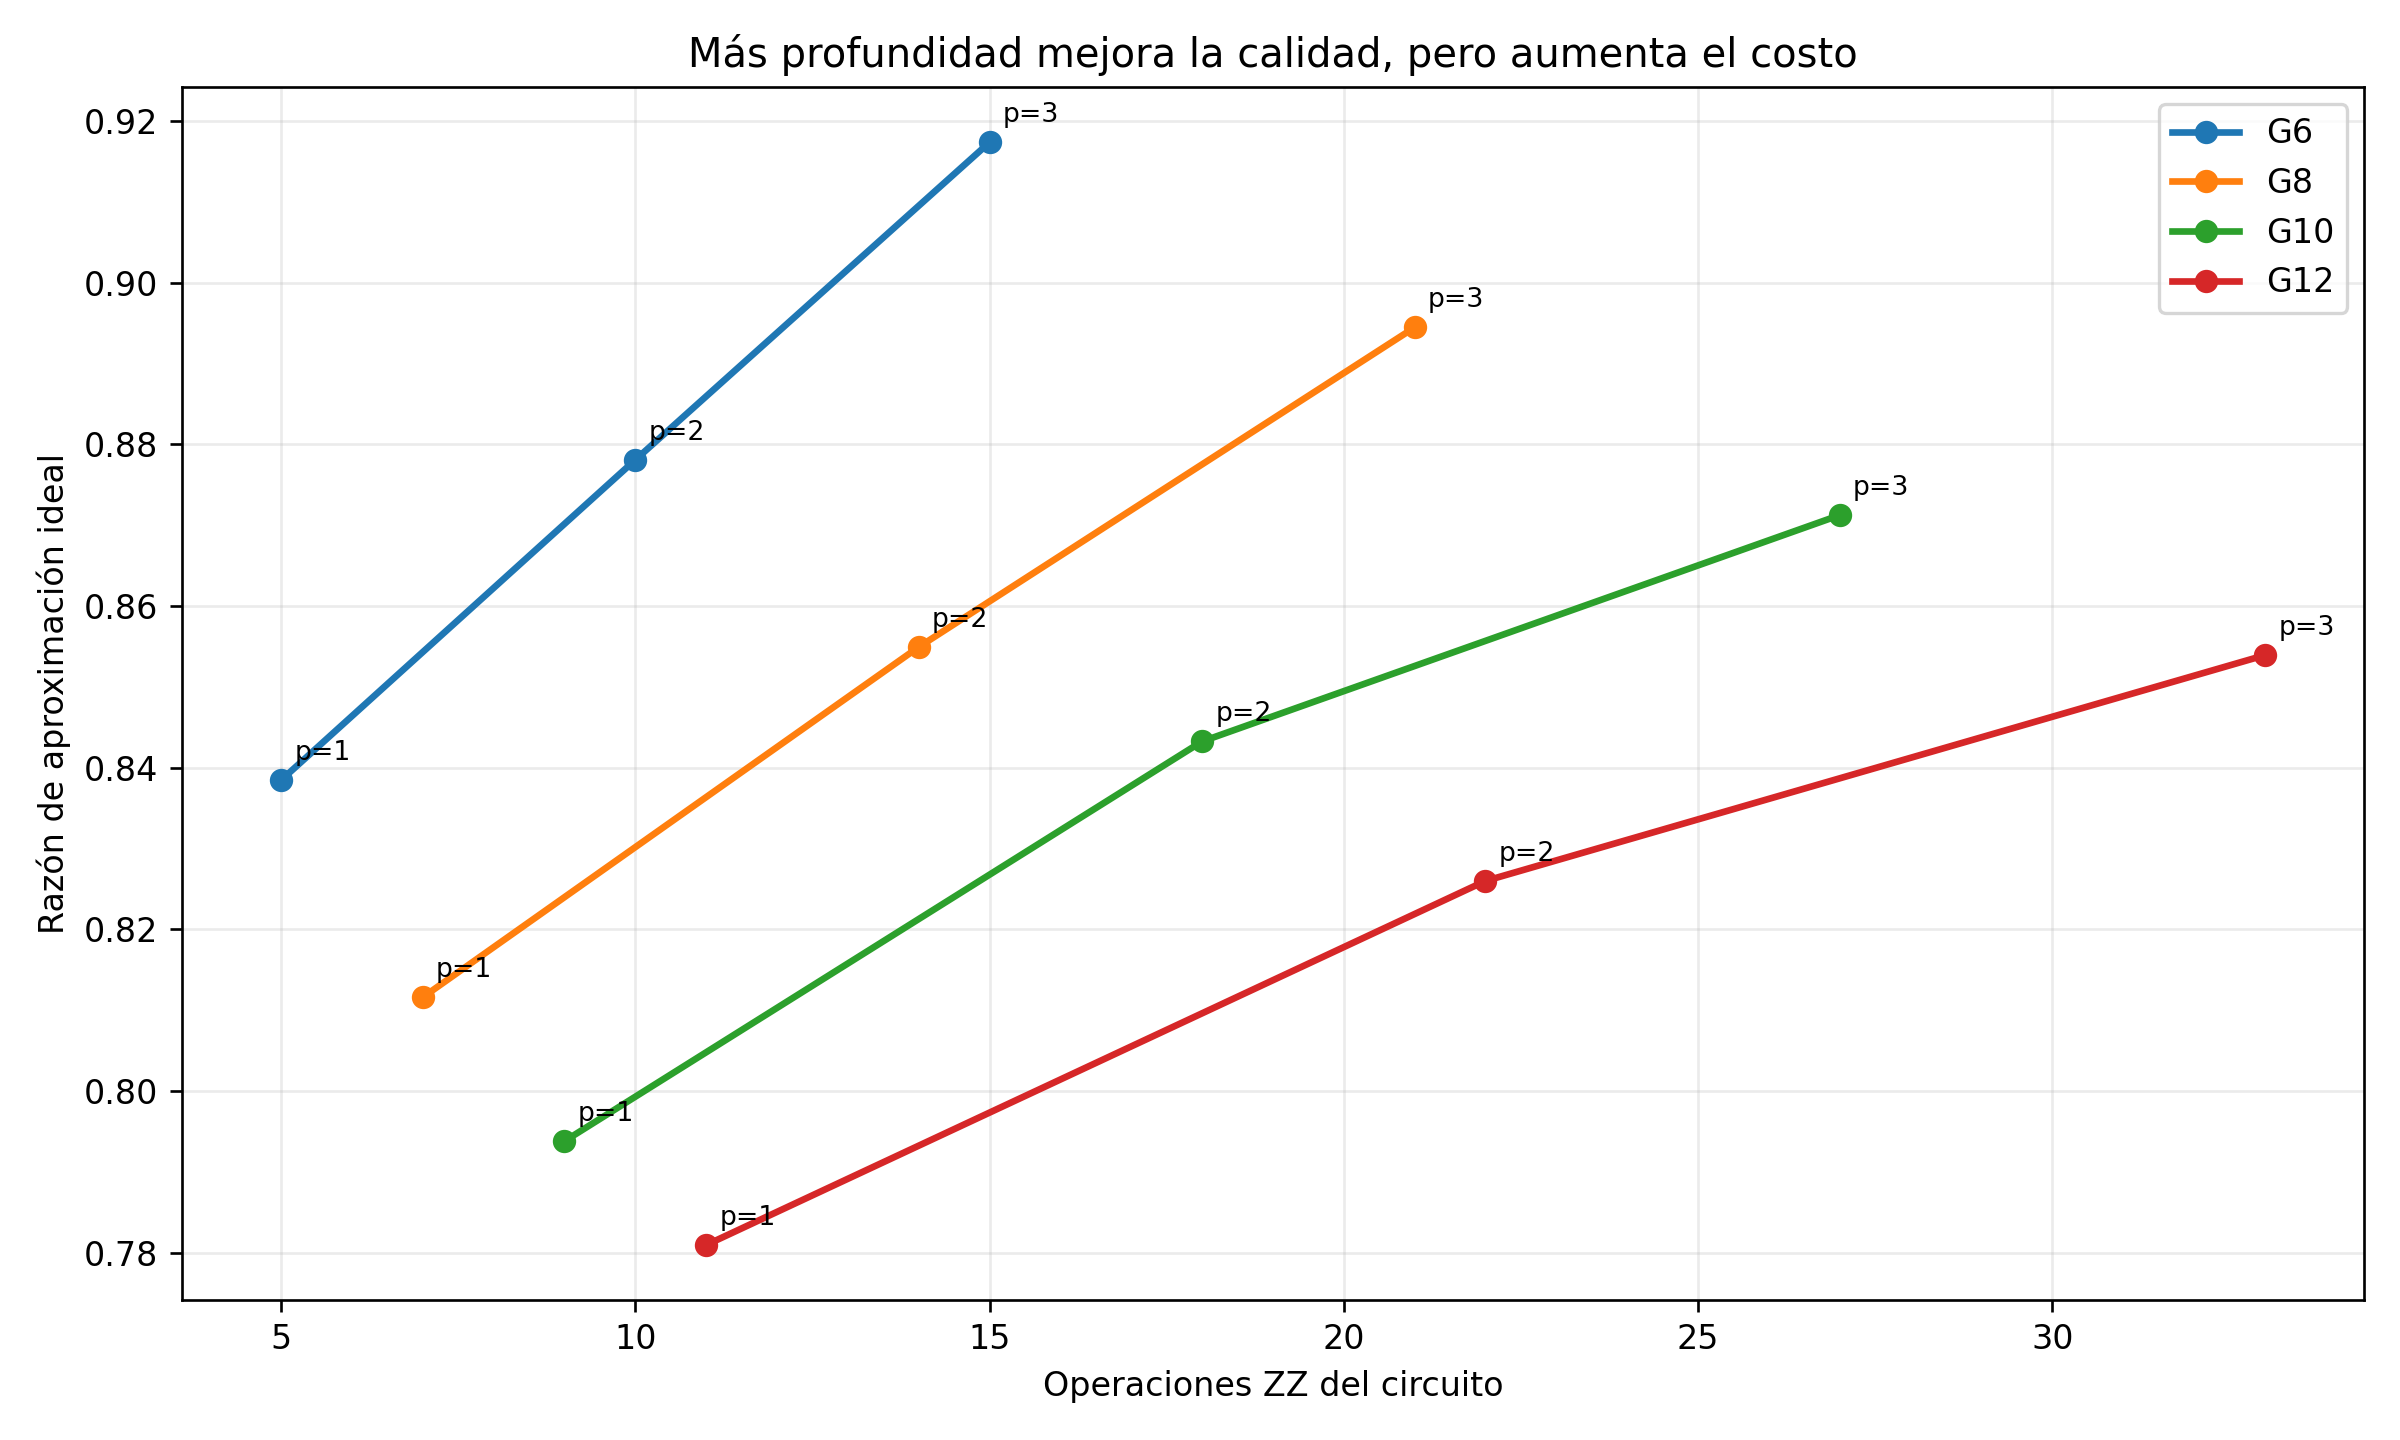

In [4]:
display(tradeoff[[
    "n", "p", "razon_ideal", "operaciones_rx", "operaciones_zz",
    "delta_razon_vs_p_anterior", "ganancia_por_zz_adicional"
]].round(6))
display(Image(filename=str(FIGURAS / "04_tradeoff_calidad_operaciones_zz.png")))

## 4. Robustez del optimizador

La entrega usa explícitamente el **mejor reinicio**, que es una práctica válida en optimización multiarranque. La distribución completa evita presentarlo como si fuera el comportamiento promedio.

,n,p,inicializaciones,convergencias,media,desviacion_estandar,minimo,maximo,indice_mejor_reinicio,mejor_reinicio,mejor_reinicio_convergio
0,6,1,6,6,0.838432,0.000000,0.838432,0.838432,4,0.838432,True
1,6,2,10,10,0.862208,0.020463,0.838432,0.878059,3,0.878059,True
2,6,3,12,12,0.894400,0.026331,0.838432,0.917346,3,0.917346,True
3,8,1,6,6,0.811577,0.000000,0.811577,0.811577,5,0.811577,True
4,8,2,10,10,0.837573,0.022374,0.811577,0.854904,7,0.854904,True
5,8,3,12,12,0.874362,0.027438,0.811577,0.894451,10,0.894451,True
6,10,1,6,6,0.793778,0.000000,0.793778,0.793778,2,0.793778,True
7,10,2,10,10,0.833336,0.020849,0.793778,0.843226,5,0.843226,True
8,10,3,12,12,0.853308,0.023226,0.793778,0.871222,4,0.871222,True
9,12,1,6,6,0.780929,0.000000,0.780929,0.780929,4,0.780929,True


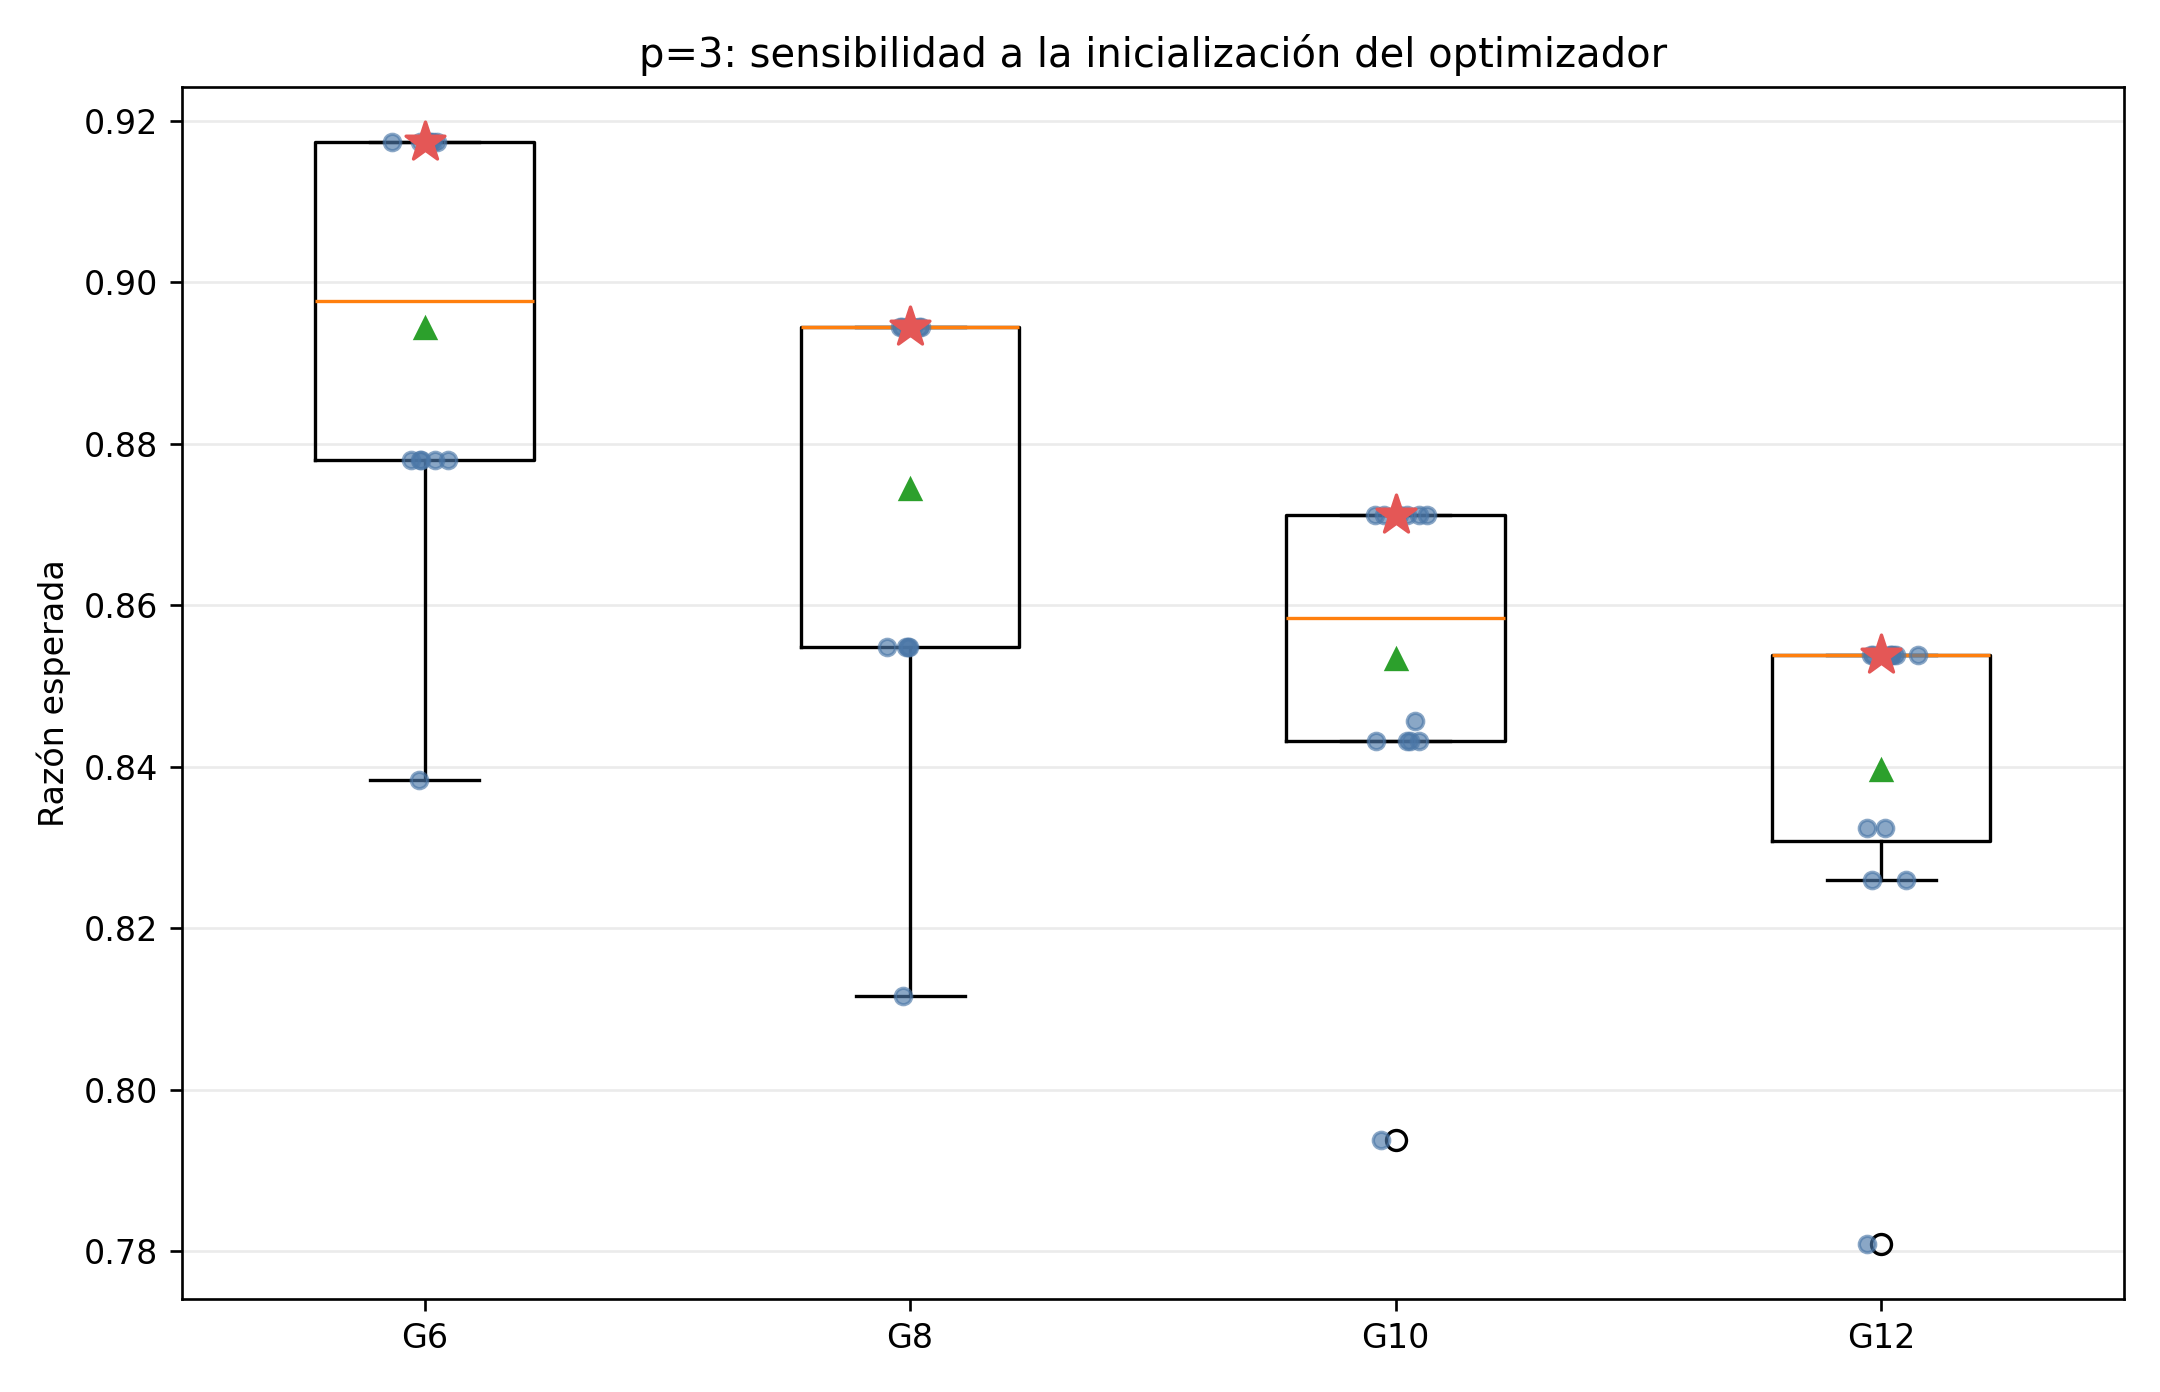

In [5]:
estadistica_inicializaciones = pd.read_csv(
    TABLAS / "04_estadistica_inicializaciones_qaoa.csv"
)
display(estadistica_inicializaciones.round(6))
display(Image(filename=str(FIGURAS / "05_robustez_reinicios_p3.png")))

## 5. SelenePlus frente al estado ideal

Existe un trabajo SelenePlus de 512 tiros por grafo; por ello se reporta la diferencia observada, pero **no** una desviación entre trabajos remotos.

In [6]:
selene = pd.read_csv(TABLAS / "03_seleneplus_vs_ideal_p3.csv")
display(selene[[
    "n", "shots", "razon_ideal", "razon_seleneplus",
    "delta_razon_selene_menos_ideal",
    "probabilidad_optimo_seleneplus", "trabajos_remotos", "estado"
]].round(6))
display(Image(filename=str(FIGURAS / "06_ideal_vs_seleneplus_p3.png")))

,n,shots,razon_ideal,razon_seleneplus,delta_razon_selene_menos_ideal,probabilidad_optimo_seleneplus,trabajos_remotos,estado
0,6,512,0.917346,0.672668,-0.244678,0.0,1,COMPLETED
1,8,512,0.894451,0.518092,-0.376358,0.0,1,COMPLETED
2,10,512,0.871222,0.514636,-0.356587,0.0,1,COMPLETED
3,12,512,0.853893,0.500611,-0.353282,0.0,1,COMPLETED


## Conclusión y límites

- En los cuatro grafos, aumentar de p=1 a p=3 mejora la calidad esperada, pero triplica las operaciones ZZ.
- La ganancia marginal por ZZ disminuye con más claridad en G10 y G12.
- En G12, p=3, la razón ideal es cercana a 0.854 y la probabilidad ideal de óptimo por tiro es cercana a 1.49 %; que aparezca un óptimo dentro de 512 tiros no significa que la distribución sea óptima.
- Los resultados SelenePlus son cercanos a los ideales en este único trabajo por grafo, pero no permiten estimar estabilidad entre trabajos remotos.
- G6, G8, G10 y G12 son árboles bipartitos con pesos positivos. El óptimo clásico corta todas las aristas, por lo que estas instancias validan el flujo QUBO/QAOA, pero no prueban ventaja cuántica ni dificultad clásica representativa.